<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/GAN_lstm_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [4]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [5]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [6]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [7]:
data_train = pd.read_table('./data/trips_SV_train.csv', sep = ',')
data_train['datetime'] = pd.to_datetime(data_train['datetime'], format='%Y-%m-%d %H:%M:%S')

data_test = pd.read_table('./data/trips_SV_test.csv', sep = ',')
data_test['datetime'] = pd.to_datetime(data_test['datetime'], format='%Y-%m-%d %H:%M:%S')

In [8]:
data = pd.concat([data_train, data_test])

In [9]:
padding = 24
resolution = 60

traj_lon = np.zeros((len(data.trip.unique()), padding))
traj_lat = np.zeros((len(data.trip.unique()), padding))

i = 0
for tt in data.trip.unique():
    traj = data[data.trip == tt].copy()
    coord = traj.loc[:,('lon_std', 'lat_std')].to_numpy()
    coord = coord[np.arange(0, coord.shape[0], resolution),:]

    idx = np.random.randint(padding - coord.shape[0] - 1)
    traj_lon[i, idx:idx+coord.shape[0]] = coord[:,0]
    traj_lat[i, idx:idx+coord.shape[0]] = coord[:,1]
    i += 1

In [10]:
class TrajDataSet(Dataset):
    def __init__(self,  lon, lat, transform=None):
        self.lon = lon
        self.lat = lat 
        self.transform = transform

    def __len__(self):
        return self.lon.shape[0]

    def __getitem__(self, idx):
        
        # select coordinates
        sample = np.stack([self.lon[idx,:], self.lat[idx,:]])

        if self.transform:
            sample = self.transform(sample)

        return sample

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        return torch.FloatTensor(sample)

In [14]:
# hyperparameters
batch_size = 30
resolution = 60
padding = 24

## reduce size dataset
train_set = TrajDataSet(traj_lon, traj_lat, transform= ToTensor())
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [15]:
x =  next(iter(train_loader))

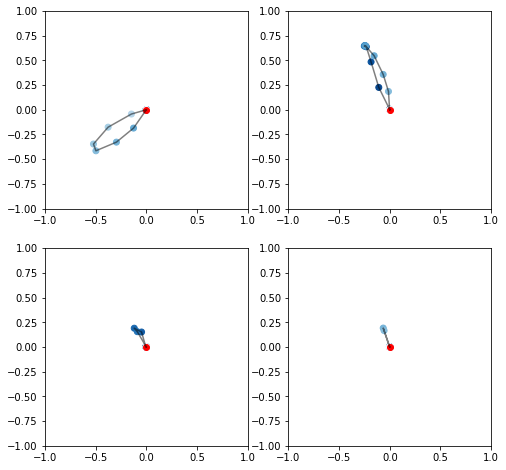

In [16]:
plt.figure(figsize = (8,8))
i = 4

for i in range(4):
  plt.subplot(2,2,i+1)
  plt.plot(x.numpy()[i,0,:], x.numpy()[i,1,:], c = 'black', alpha = 0.5)
  plt.scatter(x.numpy()[i,0,:], x.numpy()[i,1,:], c=np.arange(padding), cmap='Blues_r')
  plt.scatter(0,0, c = 'red')
  plt.xlim(-1,1)
  plt.ylim(-1,1)

## deep networks

In [45]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [46]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """

    def __init__(self):
        super().__init__()
        
        self.lstm_1 = nn.LSTM(input_size=1, hidden_size = 16, num_layers = 1)
        self.act_1 = nn.Sequential(
            nn.Tanh()
        )
        self.lstm_2 = nn.LSTM(input_size=16, hidden_size = 2, num_layers = 1)
        self.act_2 = nn.Sequential(
            nn.Tanh()
        )

    def forward(self, z):

        # init LSTM cells (num_layers, batch, hidden_size)
        out, _ = self.lstm_1(z)
        out = self.act_1(out)
        out, _ = self.lstm_2(out)
        out = self.act_2(out)
        
        return out.view(24, batch_size, 2)

In [47]:
gen = LSTMGenerator()
z = torch.rand((24, batch_size, 1)) # (len, batch, features)

out = gen(z)
out.shape

torch.Size([24, 30, 2])

In [48]:
class LSTMDiscriminator(nn.Module):
    """An LSTM based discriminator. It expects a sequence as input and outputs a probability for each element. 
    Args:
        in_dim: Input noise dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Inputs: sequence of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, 1)
    """

    def __init__(self):
        super().__init__()

        self.lstm_1 = nn.LSTM(2, 16, 1, batch_first=True)
                 
        self.lstm_2 = nn.LSTM(16, 1, 1, batch_first=True)

        self.linear = nn.Sequential(
            nn.Linear(24, 1),
            nn.Sigmoid()
            )


    def forward(self, x):        
        # init LSTM cells (num_layers, batch, hidden_size)
        out, _ = self.lstm_1(x.view(24, batch_size, 2))
        out, _ = self.lstm_2(out)
        out = self.linear(out.contiguous().view(batch_size, 24))
        return out


In [49]:
dis = LSTMDiscriminator()
dis(x).shape

torch.Size([30, 1])

# training

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = LSTMGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

# ### WEIGHT INITIALIZATION
# generator.apply(weights_init)
# discriminator.apply(weights_init)

criterion = nn.BCELoss()

lr = 0.0002
optim_d = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
optim_g = optim.Adam(generator.parameters(),lr= lr, betas=(0.5, 0.999))

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

In [51]:
# Train the model
nb_epoch = 1000

for epoch in range(nb_epoch):
    i = 0

    # if epoch%50 == 0:
    #     lr /= 10
    #     optim_d = optim.Adam(discriminator.parameters(), lr=lr)
    #     optim_g = optim.Adam(generator.parameters(),lr=lr)

    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, x in enumerate(train_loader):
        
        i+= 1
        #### TRAIN DISCRIMINATOR
        ## true samples
        x = x.to(device)

        discriminator.zero_grad()
        pred_real = discriminator(x)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((24, batch_size, 1), device=device)
        with torch.no_grad():
            fake_samples = generator(z)
        pred_fake = discriminator(fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((24, batch_size, 1), device=device) 

        generated = generator(z)
        classifications = discriminator(generated)
        loss = criterion(classifications, target_ones)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
    
    if epoch%100 == 0:
        print('Epoch [{}/{}] -----------------------------------------------------------------------------'
            .format(epoch+1, nb_epoch, i, len(train_loader)))
        print('G: {}, Dr : {}, Df : {}'
            .format(loss_g_running/batch, loss_d_real_running/batch, loss_d_fake_running/batch))

Epoch [1/1000] -----------------------------------------------------------------------------
G: 0.6947291029824151, Dr : 0.6948115428288778, Df : 0.8514248265160455
Epoch [101/1000] -----------------------------------------------------------------------------
G: 0.7483802570237054, Dr : 0.7448452644877963, Df : 0.7924392157130771
Epoch [201/1000] -----------------------------------------------------------------------------
G: 0.7807530230946012, Dr : 0.7755749622980753, Df : 0.7595865594016181
Epoch [301/1000] -----------------------------------------------------------------------------
G: 0.8581444025039673, Dr : 0.6999139189720154, Df : 0.7075342006153531
Epoch [401/1000] -----------------------------------------------------------------------------
G: 1.4490926530626085, Dr : 0.5352143612172868, Df : 0.6620189034276538
Epoch [501/1000] -----------------------------------------------------------------------------
G: 1.1271597014533148, Dr : 0.5180633299880557, Df : 0.5125209556685554


## visualizing

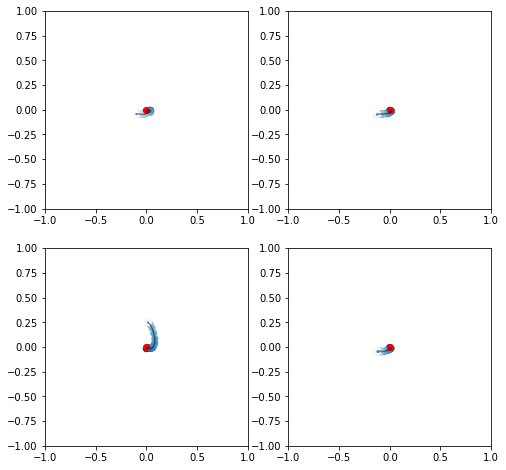

In [52]:
traj = generated.detach().numpy()

plt.figure(figsize = (8,8))

for i in range(4):
  plt.subplot(2,2,i+1)
  plt.plot(traj[:,i,0], traj[:,i,1], c = 'black', alpha = 0.5)
  plt.scatter(traj[:,i,0], traj[:,i,1], c=np.arange(padding), cmap='Blues_r')
  plt.scatter(0,0, c = 'red')
  plt.xlim(-1,1)
  plt.ylim(-1,1)

In [53]:
traj[:,i,:]

array([[-0.00220636, -0.00669906],
       [ 0.00185243, -0.00548769],
       [ 0.0065879 , -0.01016115],
       [ 0.01063724, -0.01532935],
       [ 0.01188975, -0.01287533],
       [ 0.01032702, -0.01878366],
       [ 0.00463736, -0.02119966],
       [-0.00611825, -0.02969624],
       [-0.02073722, -0.03719787],
       [-0.03577523, -0.03813935],
       [-0.05398409, -0.04755686],
       [-0.0650633 , -0.04373112],
       [-0.07843935, -0.04998871],
       [-0.08226586, -0.04211873],
       [-0.08949399, -0.04068443],
       [-0.10156297, -0.04872682],
       [-0.10410121, -0.04466357],
       [-0.11188587, -0.05025637],
       [-0.10839086, -0.04059068],
       [-0.11870106, -0.05021585],
       [-0.11500797, -0.04240959],
       [-0.12066036, -0.04575151],
       [-0.1248752 , -0.04897404],
       [-0.12226862, -0.04329794]], dtype=float32)